# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [1]:
import pandas as pd

In [2]:
df_final = pd.read_csv("df_final.csv", index_col=0, header=0)
df_final

,A,C,D,E,F,G,H,I,K,L,...,N,P,Q,R,S,T,V,W,Y,media_aa
gene,,,,,,,,,,,,,,,,,,,,,
BRCA1,112,54,95,161,44,104,49,69,107,138,...,85,105,107,97,227,104,96,10,17,90.60
HDAC1,26,10,33,48,20,37,14,23,41,31,...,22,21,15,21,27,20,27,2,28,24.10
IL6,7,4,12,15,8,8,5,11,16,28,...,14,7,10,11,11,20,11,2,6,10.55
LAMB3,100,68,62,70,30,95,22,28,41,109,...,37,57,98,95,78,62,53,11,20,58.40
TNF,17,5,10,15,11,16,3,6,11,34,...,10,13,15,7,20,8,19,2,8,11.75


In [3]:
def tendencia_central(vetor):
    media = vetor.mean()
    mediana = vetor.median()
    moda = vetor.mode()
    
    return {
        "media": media,
        "mediana": mediana,
        "moda": moda.values
    }

In [4]:
resultado_serina = tendencia_central(df_final["S"])
resultado_serina

{'media': np.float64(72.6),
 'mediana': np.float64(27.0),
 'moda': array([ 11,  20,  27,  78, 227])}

In [5]:
gene_il6 = df_final.iloc[2]
resultado_il6 = tendencia_central(gene_il6)
resultado_il6

{'media': np.float64(10.55),
 'mediana': np.float64(10.55),
 'moda': array([11.])}

## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [6]:
def amplitude(vetor):
    return vetor.max() - vetor.min()

In [7]:
amp_I = amplitude(df_final["I"])
print("Amplitude da Isoleucina:", amp_I)

Amplitude da Isoleucina: 63


In [8]:
ultimo_gene = df_final.iloc[-1]

amp_ultimo = amplitude(ultimo_gene)
print("Amplitude do último gene:", amp_ultimo)

Amplitude do último gene: 32.0


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [9]:
def quartis(vetor):
    return {
        "Q1": vetor.quantile(0.25),
        "Q2": vetor.quantile(0.50),  # mediana
        "Q3": vetor.quantile(0.75)
    }

In [18]:
q_metionina = quartis(df_final["M"])
print("Quartis da Metionina:", q_metionina)

Quartis da Metionina: {'Q1': np.float64(5.0), 'Q2': np.float64(16.0), 'Q3': np.float64(31.0)}


In [17]:
primeiro_gene = df_final.iloc[0]

q_gene = quartis(primeiro_gene)
print("Quartis do gene BRCA1:", q_gene)

Quartis do gene BRCA1: {'Q1': np.float64(54.0), 'Q2': np.float64(96.0), 'Q3': np.float64(107.0)}


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [13]:
def iqr(vetor):
    q1 = vetor.quantile(0.25)
    q3 = vetor.quantile(0.75)
    return q3 - q1

In [14]:
iqr_E = iqr(df_final["E"])
print("IQR do ácido glutâmico:", iqr_E)

IQR do ácido glutâmico: 55.0


In [16]:
penultimo_gene = df_final.iloc[-2]

iqr_gene = iqr(penultimo_gene)
print("IQR do gene LAMB3:", iqr_gene)

IQR do gene LAMB3: 46.0


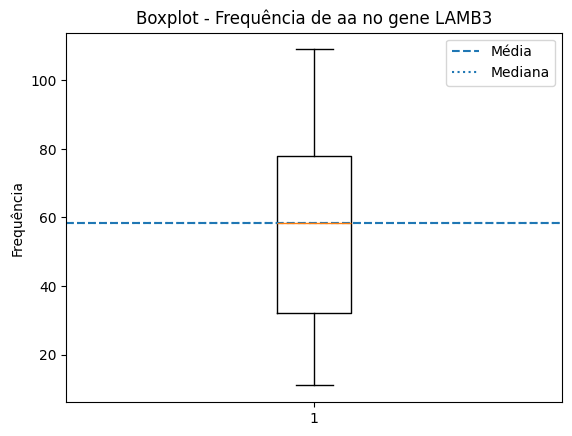

In [24]:
#boxplot
import matplotlib.pyplot as plt

valores = penultimo_gene

media = valores.mean()
mediana = valores.median()

plt.boxplot(valores, vert=True)
plt.axhline(media, linestyle="--", label="Média")
plt.axhline(mediana, linestyle=":", label="Mediana")

plt.title("Boxplot - Frequência de aa no gene LAMB3")
plt.ylabel("Frequência")

plt.legend()
plt.show()

In [25]:
#Aqui são os valores usados pra fazer o boxplot, caso queiram conferir ;)
valores = df_final.iloc[-2].astype(float)

q1 = valores.quantile(0.25)
mediana = valores.quantile(0.50)
q3 = valores.quantile(0.75)
media = valores.mean()
minimo = valores.min()
maximo = valores.max()

print("Mínimo:", minimo)
print("Q1:", q1)
print("Mediana (Q2):", mediana)
print("Q3:", q3)
print("Máximo:", maximo)
print("Média:", media)
print("IQR:", q3 - q1)

Mínimo: 11.0
Q1: 32.0
Mediana (Q2): 58.400000000000006
Q3: 78.0
Máximo: 109.0
Média: 58.400000000000006
IQR: 46.0


## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [26]:
def variancia(vetor):
    return vetor.var(ddof=1)

In [27]:
var_P = variancia(df_final["P"])
print("Variância da Prolina:", var_P)

Variância da Prolina: 1672.8000000000002


In [28]:
terceiro_gene = df_final.iloc[2].astype(float)

var_gene = variancia(terceiro_gene)
print("Variância do gene IL-6:", var_gene)

Variância do gene IL-6: 34.7475


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [29]:
def desvio_padrao(vetor):
    return vetor.std(ddof=1)

In [30]:
dp_W = desvio_padrao(df_final["W"])
print("Desvio padrão do Triptofano:", dp_W)

Desvio padrão do Triptofano: 4.669047011971501


In [31]:
ultimo_gene = df_final.iloc[-1].astype(float)

dp_gene = desvio_padrao(ultimo_gene)
print("Desvio padrão do TNF:", dp_gene)

Desvio padrão do TNF: 7.20329785584353


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [32]:
def coef_variacao(vetor):
    media = vetor.mean()
    dp = vetor.std(ddof=1)
    return dp / media

In [33]:
cv_L = coef_variacao(df_final["L"])
print("Coeficiente de variação da Leucina:", cv_L)

Coeficiente de variação da Leucina: 0.7608073702792845


In [34]:
gene_1 = df_final.iloc[1].astype(float)

cv_gene = coef_variacao(gene_1)
print("Coeficiente de variação da HDAC1:", cv_gene)

Coeficiente de variação da HDAC1: 0.43338654928785125


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [37]:
def medidas_resumo(vetor):
    media = float(vetor.mean())
    
    return {
        "media": round(media, 2),
        "mediana": round(float(vetor.median()), 2),
        "moda": vetor.mode().tolist(),
        "min": float(vetor.min()),
        "max": float(vetor.max()),
        "amplitude": float(vetor.max() - vetor.min()),
        "Q1": round(float(vetor.quantile(0.25)), 2),
        "Q2": round(float(vetor.quantile(0.50)), 2),
        "Q3": round(float(vetor.quantile(0.75)), 2),
        "IQR": round(float(vetor.quantile(0.75) - vetor.quantile(0.25)), 2),
        "variancia": round(float(vetor.var(ddof=1)), 2),
        "desvio_padrao": round(float(vetor.std(ddof=1)), 2),
        "coef_variacao": round(float(vetor.std(ddof=1) / media), 4)
    }

In [39]:
print("Serina:", medidas_resumo(df_final["S"]))

Serina: {'media': 72.6, 'mediana': 27.0, 'moda': [11, 20, 27, 78, 227], 'min': 11.0, 'max': 227.0, 'amplitude': 216.0, 'Q1': 20.0, 'Q2': 27.0, 'Q3': 78.0, 'IQR': 58.0, 'variancia': 8127.3, 'desvio_padrao': 90.15, 'coef_variacao': 1.2418}


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [40]:
def gene_maior_cv(df):
    cvs = df.apply(lambda linha: linha.std(ddof=1) / linha.mean(), axis=1)
    idx = cvs.idxmax()
    return idx, cvs[idx]

In [41]:
gene, valor = gene_maior_cv(df_final)

print("Gene com maior CV:", gene)
print("CV:", valor)

Gene com maior CV: TNF
CV: 0.6130466260292367


C:\Users\Home\AppData\Local\Temp\ipykernel_7504\319960473.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_final.T, labels=df_final.index)


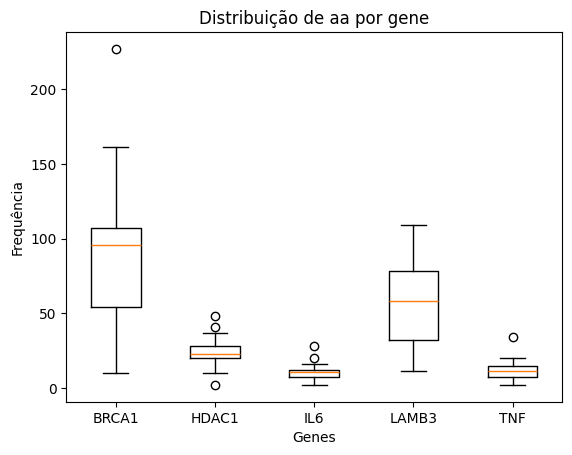

In [47]:
plt.boxplot(df_final.T, labels=df_final.index)

plt.title("Distribuição de aa por gene")
plt.xlabel("Genes")
plt.ylabel("Frequência")

plt.show()

R.: Os dados não concordam entre si. Anteriormente, o coeficiente de variação mostrou que o gene com maior variação relativa foi o TNF, e no boxplot vemos que o gnee BRCA1 tem maior dispersão absoluta. Isso ocorre porque, embora ambos avaliem a variabilidade, o coeficiente de variação é uma medida relativa normalizada pela média, enquanto o boxplot representa a dispersão absoluta com base nos quartis.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [43]:
def aa_maior_cv(df):
    cvs = df.apply(lambda col: col.std(ddof=1) / col.mean(), axis=0)
    aa = cvs.idxmax()
    return aa, cvs[aa]

In [44]:
aa, valor = aa_maior_cv(df_final)

print("aa com maior CV:", aa)
print("CV:", valor)

aa com maior CV: S
CV: 1.2417567367542623


C:\Users\Home\AppData\Local\Temp\ipykernel_7504\585309812.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_final, labels=df_final.columns)


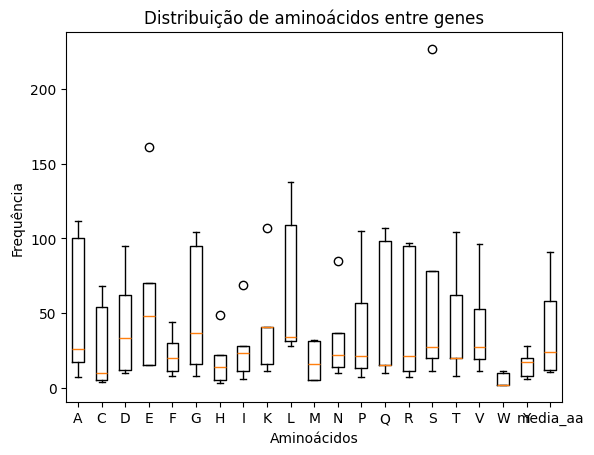

In [46]:
plt.boxplot(df_final, labels=df_final.columns)

plt.title("Distribuição de aminoácidos entre genes")
plt.xlabel("Aminoácidos")
plt.ylabel("Frequência")

plt.show()

R.: Os dados não concordam entre si, uma vez que o aminoácido com maior coeficiente de variação foi a Serina. No entanto, ao observar o boxplot, vemos que a Lisina (L) apresenta maior dispersão absoluta (maior intervalo interquartil e/ou amplitude). Isso acontece porque o coeficiente de variação é calculado com base na média dos dados e o boxplot mostra a dispersão baseada nos quartis, como explicado no exercício 09.

In [51]:
import time
from IPython.display import clear_output

In [52]:
frames = [
r"""
  /\_/\  
 ( ^.^ ) 
 /  >🎉 
""",
r"""
  /\_/\  
 ( ^.^ ) 
 🎉<  \ 
""",
r"""
  /\_/\  
 ( ^.^ ) 
 /  >🎊 
""",
r"""
  /\_/\  
 ( ^.^ ) 
 🎊<  \ 
"""
]
for _ in range(8):
    for f in frames:
        clear_output(wait=True)
        print("🎉 FINALIZADO!!! 🎉\n")
        print(f)
        time.sleep(0.3)


🎉 FINALIZADO!!! 🎉


  /\_/\  
 ( ^.^ ) 
 🎊<  \ 

